In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve


In [2]:
BASE_PATH = r"C:\Users\Agastya\Hbb-jet-tagging"

TRAIN_NPZ = BASE_PATH + r"\data\processed\train.npz"
VAL_NPZ   = BASE_PATH + r"\data\processed\val.npz"
SCALER_PKL = BASE_PATH + r"\artifacts\scaler.pkl"
MODEL_OUT  = BASE_PATH + r"\artifacts\logreg_baseline.pkl"


In [3]:
train_data = np.load(TRAIN_NPZ)
val_data   = np.load(VAL_NPZ)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)


Train shape: (159768, 12) (159768,)
Val shape: (39943, 12) (39943,)


In [4]:
print("Signal fraction (train):", y_train.mean())
print("Signal fraction (val):", y_val.mean())


Signal fraction (train): 0.1237669620950378
Signal fraction (val): 0.12377638134341437


In [5]:
scaler = joblib.load(SCALER_PKL)
print("Scaler loaded successfully")


Scaler loaded successfully


In [6]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

logreg.fit(X_train, y_train)
print("Logistic Regression trained")


Logistic Regression trained


Validation ROC-AUC: 0.9056


C:\Users\Agastya\AppData\Local\Temp\ipykernel_40652\1088737580.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr, 1 / fpr, label=f"AUC = {auc:.3f}")


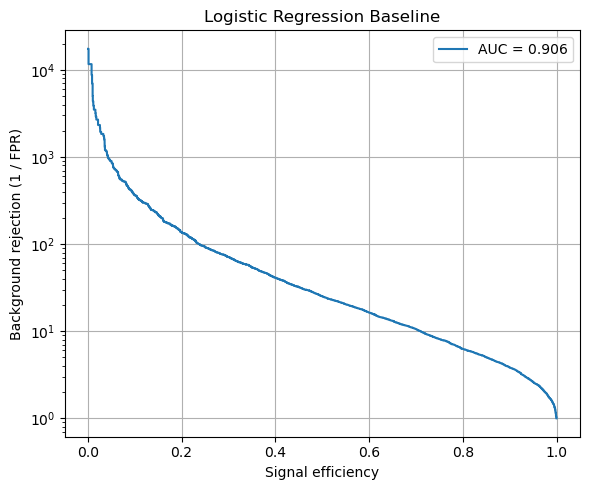

In [8]:
y_val_pred = logreg.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_val_pred)
print(f"Validation ROC-AUC: {auc:.4f}")
fpr, tpr, _ = roc_curve(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
plt.plot(tpr, 1 / fpr, label=f"AUC = {auc:.3f}")
plt.yscale("log")
plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection (1 / FPR)")
plt.grid(True)
plt.legend()
plt.title("Logistic Regression Baseline")
plt.tight_layout()
plt.show()



In [ ]:
import joblib

ARTIFACTS_DIR = r"C:\Users\Agastya\Hbb-jet-tagging\artifacts"
MODEL_PATH = os.path.join(ARTIFACTS_DIR, "logreg_baseline.pkl")

# make sure directory exists
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(logreg, MODEL_PATH)

print("Baseline model saved at:")
print(MODEL_PATH)


✅ Baseline model saved at:
C:\Users\Agastya\Hbb-jet-tagging\artifacts\logreg_baseline.pkl


In [11]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
y_val_pred_xgb = xgb.predict_proba(X_val)[:, 1]

auc_xgb = roc_auc_score(y_val, y_val_pred_xgb)
print(f"XGBoost Validation ROC-AUC: {auc_xgb:.4f}")



XGBoost Validation ROC-AUC: 0.9705


C:\Users\Agastya\AppData\Local\Temp\ipykernel_40652\64996313.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr, 1/fpr, label=f"LogReg AUC = {auc:.3f}")
C:\Users\Agastya\AppData\Local\Temp\ipykernel_40652\64996313.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr_xgb, 1/fpr_xgb, label=f"XGB AUC = {auc_xgb:.3f}")


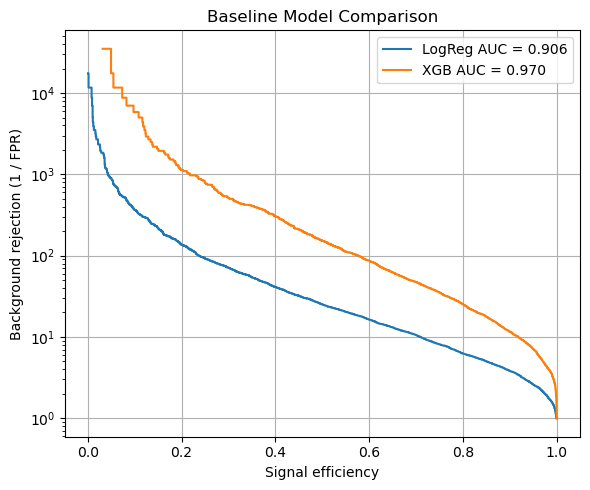

In [12]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_pred_xgb)

plt.figure(figsize=(6, 5))
plt.plot(tpr, 1/fpr, label=f"LogReg AUC = {auc:.3f}")
plt.plot(tpr_xgb, 1/fpr_xgb, label=f"XGB AUC = {auc_xgb:.3f}")
plt.yscale("log")
plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection (1 / FPR)")
plt.grid(True)
plt.legend()
plt.title("Baseline Model Comparison")
plt.tight_layout()
plt.show()


In [1]:
ARTIFACTS_DIR = r"C:\Users\Agastya\Hbb-jet-tagging\artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

XGB_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "xgb_baseline.pkl")

joblib.dump(xgb, XGB_MODEL_PATH)

print("XGBoost model saved at:", XGB_MODEL_PATH)


NameError: name 'os' is not defined